<a href="https://colab.research.google.com/github/Alaa-f-Abdalaal/Machine-Projectss/blob/main/assistance_type_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformers
!pip install torch
!pip install scikit-learn

In [2]:
import pandas as pd

df = pd.read_excel('/content/Awnn_feature_engineering (1).xlsx')

df.head()

,name,national_id,case_type,family_size,phone,amount_received,income_monthly,monthly_expenses,debts,housing_type,...,financial_gap,children_ratio,hardship_score,economic_pressure,need_urgency,income_stability,case_type_clean,health_status_clean,housing_type_clean,critical_case
0,نجلاء عبدالباسط,50370498039207,ذوي اعاقه,3,1183629898,200,-1.026332,-0.996938,-0.694062,سكن لدى الأقارب,...,-0.749068,-0.391975,-0.871999,0.087851,-0.548548,-1.087591,ذوي اعاقه,اعاقة ذهنية,سكن لدى الاقارب,1
1,حسن كمال,65150394917789,ايتام,4,1014613636,1000,1.464734,1.110307,0.679257,تمليك,...,0.641087,-1.311081,0.238951,-0.007892,-0.171734,1.449572,ايتام,اعاقة ذهنية,تمليك,0
2,فاطمة عبدالرحمن,32515235878793,ارمله,8,1013124808,1500,-0.023455,-0.087312,-0.694062,سكن لدى الأقارب,...,-0.105494,-0.277087,-0.292935,-0.010193,-0.548548,-0.071423,ارمله,اعاقة حركية,سكن لدى الاقارب,0
3,ابراهيم الهواري,46071550347522,ايتام,6,1200902016,600,0.549828,0.588317,-0.694062,تمليك,...,0.475572,-0.851528,0.115281,-0.009090,-0.548548,0.509457,ايتام,اعاقة حركية,تمليك,0
4,غير معروف,63352487361031,اسره فقيره,7,1529047284,1500,0.884120,1.033166,0.989139,تمليك,...,0.884078,-0.129373,0.823339,-0.007368,0.771784,0.715287,اسره فقيره,مريض ضغط,تمليك,1


In [3]:
drop_cols = [
    'name','national_id','phone','city','neighborhood','recommended_org'
]

df = df.drop(columns=drop_cols, errors='ignore')

In [19]:
df = df[df['assistance_type'] != 'unknown'].reset_index(drop=True)

In [20]:
X_text = df['request_text']
y = df['assistance_type']

structured_features = [
    'financial_gap',
    'hardship_score',
    'income_stability',
    'family_size',
    'children_ratio',
    'economic_pressure',
    'debt_to_income_ratio',
    'remaining_income',
    'is_deficit',
    'critical_case'
]

X_structured = df[structured_features]

In [5]:
from sklearn.model_selection import train_test_split

X_text_train, X_text_test, \
X_struct_train, X_struct_test, \
y_train, y_test = train_test_split(
    X_text, X_structured, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
from transformers import AutoTokenizer, AutoModel
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [7]:
def get_embeddings(text_series):
    embeddings = []

    for text in text_series:
        inputs = tokenizer(
            str(text),
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=128
        ).to(device)

        with torch.no_grad():
            outputs = bert_model(**inputs)

        cls_embedding = outputs.last_hidden_state[:,0,:]
        embeddings.append(cls_embedding.cpu().numpy())

    return torch.tensor(embeddings).squeeze().numpy()

In [8]:
X_text_train_emb = get_embeddings(X_text_train)
X_text_test_emb = get_embeddings(X_text_test)

/tmp/ipython-input-38964/672532091.py:19: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  return torch.tensor(embeddings).squeeze().numpy()


In [9]:
import numpy as np

X_train_final = np.concatenate(
    [X_text_train_emb, X_struct_train.values],
    axis=1
)

X_test_final = np.concatenate(
    [X_text_test_emb, X_struct_test.values],
    axis=1
)

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
          solver='lbfgs',
         n_jobs=-1,
        tol=1e-3

    ))
])

pipeline.fit(X_train_final, y_train)

y_pred = pipeline.predict(X_test_final)

Accuracy: 0.9039166666666667

F1 Macro: 0.8006402497398791

Classification Report:

                      precision    recall  f1-score   support

disability_equipment       0.89      0.95      0.92       751
           education       0.92      0.95      0.93      1534
           financial       0.90      0.95      0.93      2267
                food       0.91      0.97      0.94      2288
             housing       0.90      0.96      0.93      1499
             medical       0.95      0.94      0.95      3059
             unknown       0.03      0.01      0.01       602

            accuracy                           0.90     12000
           macro avg       0.79      0.82      0.80     12000
        weighted avg       0.87      0.90      0.89     12000



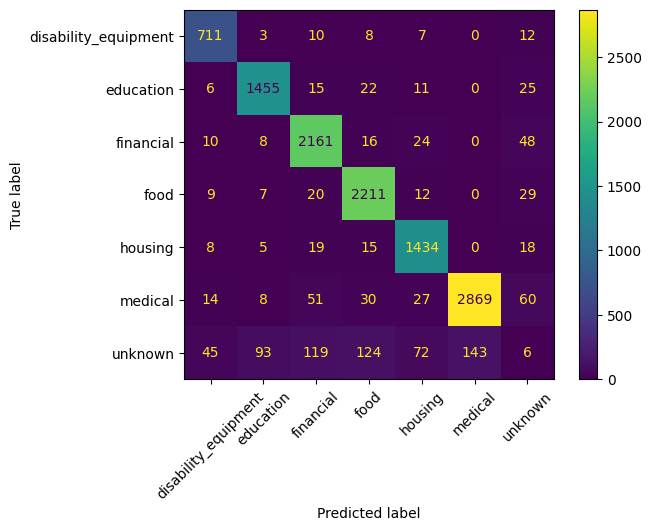

In [22]:
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# --- التقييم ---
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nF1 Macro:", f1_score(y_test, y_pred, average='macro'))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# --- مصفوفة الارتباك ---
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=pipeline.classes_
)

plt.xticks(rotation=45)
plt.show()

In [12]:
def predict_new_case(text, structured_values):

    # استخراج embedding
    emb = get_embeddings([text])

    # إجبار embedding يكون شكلها (1, n_features)
    emb = np.array(emb).reshape(1, -1)

    # structured features
    structured_array = np.array(structured_values).reshape(1, -1)

    # الدمج الصحيح
    final_input = np.hstack((emb, structured_array))

    # التنبؤ
    return pipeline.predict(final_input)[0]

In [13]:
sample_text = "I lost my job and I cannot support my family financially"

sample_structured = [
    2000,
    0.7,
    0.3,
    4,
    0.5,
    0.6,
    0.4,
    -300,
    1,
    0
]

print(predict_new_case(sample_text, sample_structured))

financial


In [14]:
sample_text = "المريض يحتاج دعم تعليمي"
sample_structured = [
    5000,
    0.9,
    0.4,
    6,
    0.7,
    0.8,
    0.6,
    -1000,
    1,
    1
]

print(predict_new_case(sample_text, sample_structured))

financial


In [15]:
print(df['assistance_type'].value_counts())

assistance_type
medical                 15296
food                    11441
financial               11332
education                7669
housing                  7494
disability_equipment     3756
unknown                  3012
Name: count, dtype: int64


In [16]:
print(predict_new_case("I need medical help urgently", sample_structured))
print(predict_new_case("I cannot pay school fees", sample_structured))

financial
financial


In [17]:
texts = [
    "I need medical treatment urgently",
    "I cannot pay school fees",
    "I am hungry and need food",
    "I lost my job and cannot pay rent",
    "I need wheelchair equipment"
]

for t in texts:
    print(t, " → ", predict_new_case(t, sample_structured))

I need medical treatment urgently  →  financial
I cannot pay school fees  →  financial
I am hungry and need food  →  financial
I lost my job and cannot pay rent  →  financial
I need wheelchair equipment  →  financial


In [18]:
print(df[['request_text','assistance_type']].head(20))

                                         request_text       assistance_type
0   نجلاء عبدالباسط من ذوي إعاقة مقيم في المطرية و...  disability_equipment
1   حسن كمال من أيتام مقيم في إمبابة ويحتاج: تحتاج...                  food
2   فاطمة عبدالرحمن من أرملة مقيم في سان ستيفانو و...             education
3   إبراهيم الهواري من أيتام مقيم في العطارين ويحت...             financial
4   آمال النجار من أسرة فقيرة مقيم في المحلة الكبر...                  food
5   آمال أنور من أرملة مقيم في مدينة نصر ويحتاج: ت...                  food
6   نجلاء عبدالله من أسرة فقيرة مقيم في المحلة الك...             financial
7   مراد النجار من ذوي إعاقة مقيم في العطارين ويحت...               medical
8   محمود أنور من أيتام مقيم في حلوان ويحتاج: تحتا...                  food
9   صفاء النجار من ذوي إعاقة مقيم في شبرا ويحتاج: ...  disability_equipment
10  علي مراد من أرملة مقيم في سان ستيفانو ويحتاج: ...                  food
11  محمود سليم من أسرة فقيرة مقيم في مدينة نصر ويح...                  food
12  أمينة عب

In [23]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train_final, y_train_enc)

y_pred_xgb = xgb.predict(X_test_final)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_enc,
    y_pred_xgb,
    target_names=le.classes_
))

In [ ]:
import matplotlib.pyplot as plt

importances = xgb.feature_importances_

plt.figure()
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance")
plt.xlabel("Feature Index")
plt.ylabel("Importance Score")
plt.show()